# Speed comparision at x86-64 and ARMv8 platform

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate a speed comparision diagram for model 1a (exponential distribution) shown in the report.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Load and process data

In [2]:
file_ryzen = "statistics/results1Exp.txt"  # AMD Ryzen 9 3900XT
file_raspi = "statistics/results1Exp-raspberrypi.txt"  # Raspberry Pi 4B

df_ryzen = pd.read_csv(file_ryzen, header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t")
df_raspi = pd.read_csv(file_raspi, header=None, names=["rng_mode", "n", "mean", "std", "delta2", "time"], sep="\t")

generators = list(set(df_ryzen["rng_mode"].drop_duplicates().tolist()) & set(df_raspi["rng_mode"].drop_duplicates().tolist()))

In [3]:
# Mean value per generator (100 runs were done per generator)
times_ryzen = []
times_raspi = []
for generator in generators:
    times_ryzen.append(df_ryzen[df_ryzen["rng_mode"] == generator]["time"].mean())
    times_raspi.append(df_raspi[df_raspi["rng_mode"] == generator]["time"].mean())

# Data frame consisting of generator name and time
df_times_ryzen = pd.DataFrame({"generator": generators, "time_ryzen": times_ryzen}, index=generators)
df_times_raspi = pd.DataFrame({"generator": generators, "time_raspi": times_raspi}, index=generators)

# Sorted data frame
df_times_ryzen_sorted = df_times_ryzen.sort_values("time_ryzen", ascending=True).reset_index(drop=True)
df_times_raspi_sorted = df_times_raspi.sort_values("time_raspi", ascending=True).reset_index(drop=True)

# Get fastest time for x86-64 and ARMv8 (to display percent values in diagram)
fastest_time_ryzen = df_times_ryzen_sorted.iloc[0]["time_ryzen"]
fastest_time_raspi = df_times_raspi_sorted.iloc[0]["time_raspi"]

# Add index
df_times_ryzen_sorted["rank_ryzen"] = df_times_ryzen_sorted.index + 1
df_times_raspi_sorted["rank_raspi"] = df_times_raspi_sorted.index + 1

# Merge data for x86-64 and ARMv8
df_merged = pd.merge(df_times_ryzen_sorted[["generator", "time_ryzen", "rank_ryzen"]], df_times_raspi_sorted[["generator", "time_raspi", "rank_raspi"]], on="generator")

### Colors for generator types

In [4]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

is_reflection=["XoRoShiRo256++", "L64X128Mix", "L64X128**", "L64X256Mix", "L64X1024Mix", "L128X128Mix", "L128X256Mix", "L128X1024Mix"]

def gen_full_name(generator):
    if generator=="ThreadLocalRandomSlow":
        return "ThreadLocalRandom.current() (**)"
    if generator in is_reflection:
        return generator+" (*)"
    return generator

## Generate diagram

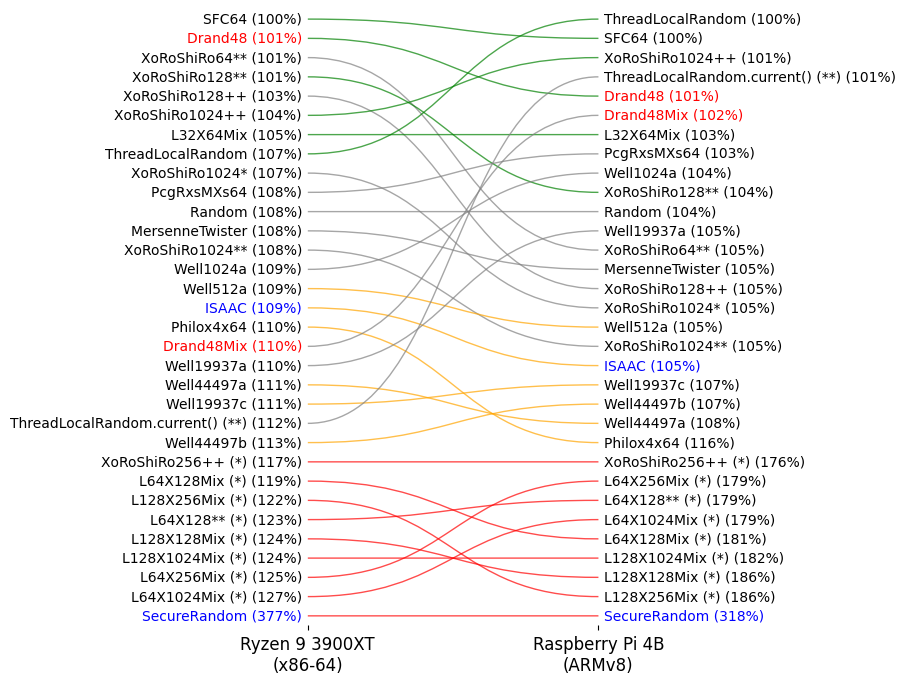

In [ ]:
# For the diagram: left x position = 0, right x position = 1
x_left, x_right = 0, 1

fig, ax = plt.subplots(figsize=(6, 8))

for _, row in df_merged.iterrows():
    # Get data for generator
    time_left = round(row["time_ryzen"] / fastest_time_ryzen * 100)
    time_right = round(row["time_raspi"] / fastest_time_raspi * 100)
    y_left = row["rank_ryzen"]
    y_right = row["rank_raspi"]
    gen = row["generator"]

    # Average rank (for color of connection line)
    average_rank = (row["rank_raspi"] + row["rank_ryzen"]) / (len(df_merged) * 2)
    if average_rank < 0.25:
        color = "green"
    elif average_rank < 0.50:
        color = "gray"
    elif average_rank < 0.75:
        color = "orange"
    else:
        color = "red"

    # Connection line
    verts = [(x_left, y_left), (0.5, y_left), (0.5, y_right), (x_right, y_right)]
    codes = [patches.Path.MOVETO, patches.Path.CURVE4, patches.Path.CURVE4, patches.Path.CURVE4]  # pyright: ignore[reportAttributeAccessIssue]
    path = patches.Path(verts, codes)  # pyright: ignore[reportAttributeAccessIssue]
    patch = patches.PathPatch(path, edgecolor=color, facecolor="none", alpha=0.7)
    ax.add_patch(patch)

    # Points
    # ax.scatter([x_left], [y_left], color="blue", s=30)
    # ax.scatter([x_right], [y_right], color="red", s=30)

    # Labels
    ax.text(x_left - 0.02, y_left, gen_full_name(gen) + " (" + str(time_left) + "%)", ha="right", va="center", color=color_from_name(gen))
    ax.text(x_right + 0.02, y_right, gen_full_name(gen) + " (" + str(time_right) + "%)", ha="left", va="center", color=color_from_name(gen))

# Setup axis
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(0.5, len(df_merged) + 0.5)
ax.invert_yaxis()  # Rang 1 at top

ax.set_xticks([x_left, x_right])
ax.set_xticklabels(["Ryzen 9 3900XT\n(x86-64)", "Raspberry Pi 4B\n(ARMv8)"], fontsize=12)

ax.set_yticks([])  # no y axis labels

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)
ax.spines["left"].set_visible(False)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot1platforms.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

# fig.savefig("plot1platforms.png", format="png", bbox_inches='tight', pad_inches=0)